# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [94]:
# !pip install mat73 h5py

In [95]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [96]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    '../data'
)

files = sorted(os.listdir("."))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join("", f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : ../data
파일 목록 :
   ESSHealth-scratch.ipynb  (0.0 GB)


## Loading

- `.mat` 파일은 MATLAB 형식이며, 이 파일은 **MATLAB v7.3(HDF5)** 포맷임
- 먼저 `scipy.io.loadmat()`을 시도하고, v7.3이면 `mat73`로 fallback 함
- 파일 크기가 크므로 **Batch 1** 하나만 먼저 로드함

In [97]:
# Batch 로드 (가장 많이 사용되는 기본 배치)
batch1_path = os.path.join(DATA_DIR, '2017-05-12_batchdata_updated_struct_errorcorrect.mat')
batch2_path = os.path.join(DATA_DIR, '2018-02-20_batchdata_updated_struct_errorcorrect.mat')
batch3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')

def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat1 = load_mat(batch1_path)
mat2 = load_mat(batch2_path)
mat3 = load_mat(batch3_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat1.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)
로드 완료 (MATLAB v7.3 / HDF5 형식)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로드 완료 (MATLAB v7.3 / HDF5 형식)
로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [126]:
batch = mat3['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [127]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 5C_67PER_4C_NEWSTRUCTURE
  policy_readable           | str      | 5C(67%)-4C-newstructure
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [128]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1008

사이클[0] 내 변수 목록 :
  I               | ndarray | shape=(762,) | dtype=float64
  Qc              | ndarray | shape=(762,) | dtype=float64
  Qd              | ndarray | shape=(762,) | dtype=float64
  Qdlin           | ndarray | shape=(1000,) | dtype=float64
  T               | ndarray | shape=(762,) | dtype=float64
  Tdlin           | ndarray | shape=(1000,) | dtype=float64
  V               | ndarray | shape=(762,) | dtype=float64
  discharge_dQdV  | ndarray | shape=(1000,) | dtype=float64
  t               | ndarray | shape=(762,) | dtype=float64


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [129]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d  # 이미 list 형태면 그대로 반환

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        # mat73은 summary도 dict-of-lists → 각 필드를 직접 접근
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = float(np.asarray((cell['cycle_life'])))
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)

In [130]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (51007, 11)


,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,0,1,1009.0,5C(67%)-4C-newstructure,1.066573,1.066090,0.015435,33.433834,32.149495,30.830272,10.043408
1,0,2,1009.0,5C(67%)-4C-newstructure,1.067455,1.066964,0.015399,33.403964,32.106606,30.779943,10.043255
2,0,3,1009.0,5C(67%)-4C-newstructure,1.068285,1.067611,0.015365,33.325268,32.088511,30.824746,10.042333
3,0,4,1009.0,5C(67%)-4C-newstructure,1.068708,1.068164,0.015326,33.304202,32.086306,30.804544,10.052677
4,0,5,1009.0,5C(67%)-4C-newstructure,1.069094,1.068695,0.015309,33.257191,32.041147,30.791834,10.042382


In [131]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,51007.000,51007.000,46581.000,51007.000,51007.000,51007.000,51007.000,51007.000,51007.000,51007.000
mean,23.331,621.448,1150.600,1.028,1.028,0.016,38.529,35.500,32.598,10.470
std,13.473,442.300,349.576,0.043,0.042,0.001,2.402,1.692,1.023,0.711
min,0.000,1.000,541.000,0.880,0.880,0.010,31.209,31.003,28.032,10.024
25%,12.000,278.000,858.000,1.014,1.014,0.015,36.899,34.183,31.863,10.043
50%,23.000,555.000,1048.000,1.042,1.042,0.015,38.916,35.565,32.491,10.054
75%,35.000,855.000,1284.000,1.059,1.058,0.016,40.194,36.769,33.365,11.038
max,45.000,2237.000,1935.000,1.100,1.103,0.021,44.663,41.440,36.691,24.003


In [132]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id               0
cycle                 0
cycle_life         4426
charging_policy       0
QD                    0
QC                    0
IR                    0
Tmax                  0
Tavg                  0
Tmin                  0
chargetime            0
dtype: int64


In [133]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 8


## EDA(Basic)

### 1. Cycle Life 분포

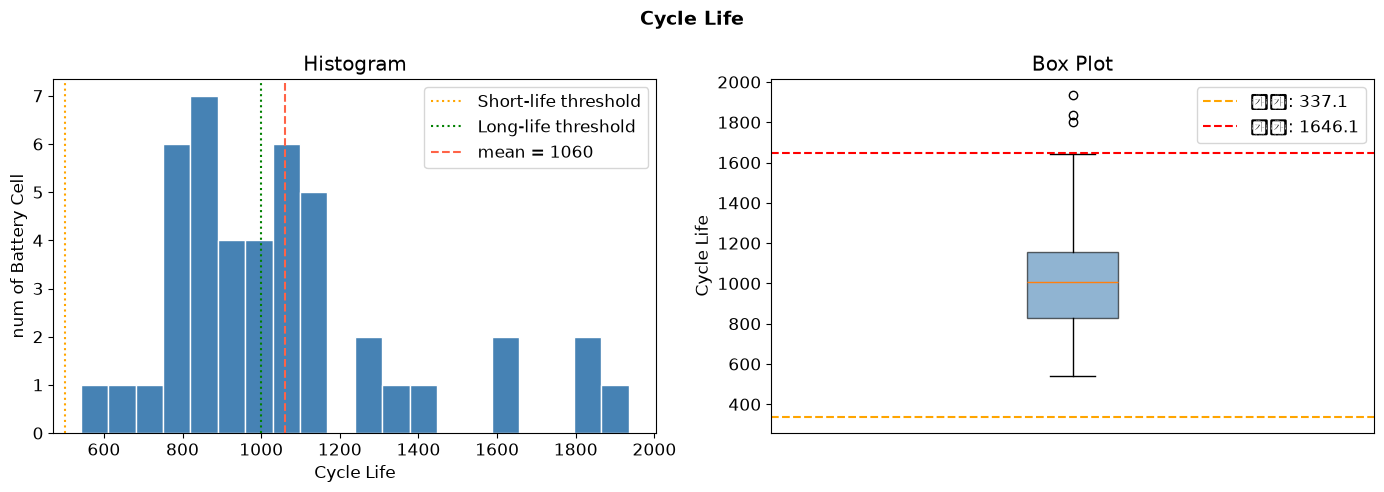

count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0
Name: cycle_life, dtype: float64
장수명 (>1,000): 23개, 52.3%
단수명 (<500): 0개, 0.0%
IQR 이상치 기준: 337.1 미만 또는 1646.1 초과
기준 밖 배터리: 3개


In [134]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]
life = cycle_life_df['cycle_life'].dropna()
q1, q3 = life.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(life, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(500, color='orange', linestyle=':', label='Short-life threshold')
axes[0].axvline(1000, color='green', linestyle=':', label='Long-life threshold')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(life.mean(), color='tomato', linestyle='--',
                label=f"mean = {life.mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(life, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].axhline(lower, color='orange', linestyle='--', label=f'하한: {lower:.1f}')
axes[1].axhline(upper, color='red', linestyle='--', label=f'상한: {upper:.1f}')
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])
axes[1].legend()

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

print(f"장수명 (>1,000): {(life > 1000).sum()}개, {(life > 1000).mean():.1%}")
print(f"단수명 (<500): {(life < 500).sum()}개, {(life < 500).mean():.1%}")
print(f"IQR 이상치 기준: {lower:.1f} 미만 또는 {upper:.1f} 초과")
print(f"기준 밖 배터리: {((life < lower) | (life > upper)).sum()}개")

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

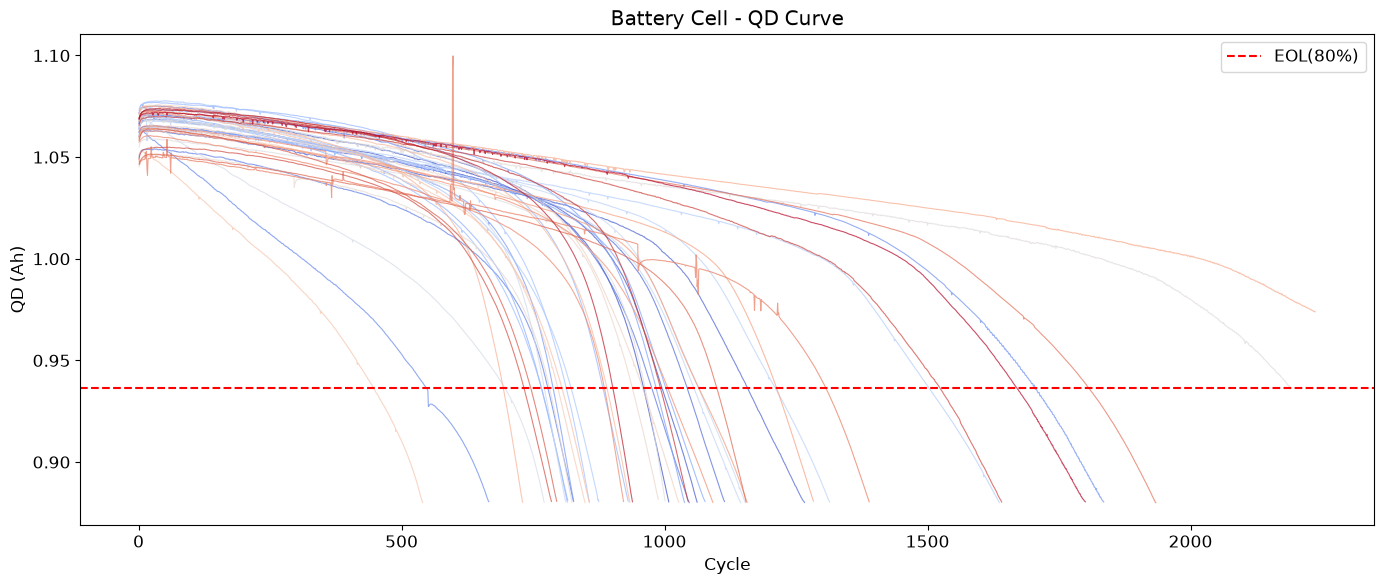

In [135]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0665 Ah
필터 범위          : 0.8532 ~ 1.2799 Ah
제거된 행 수       : 0 (0.00%)


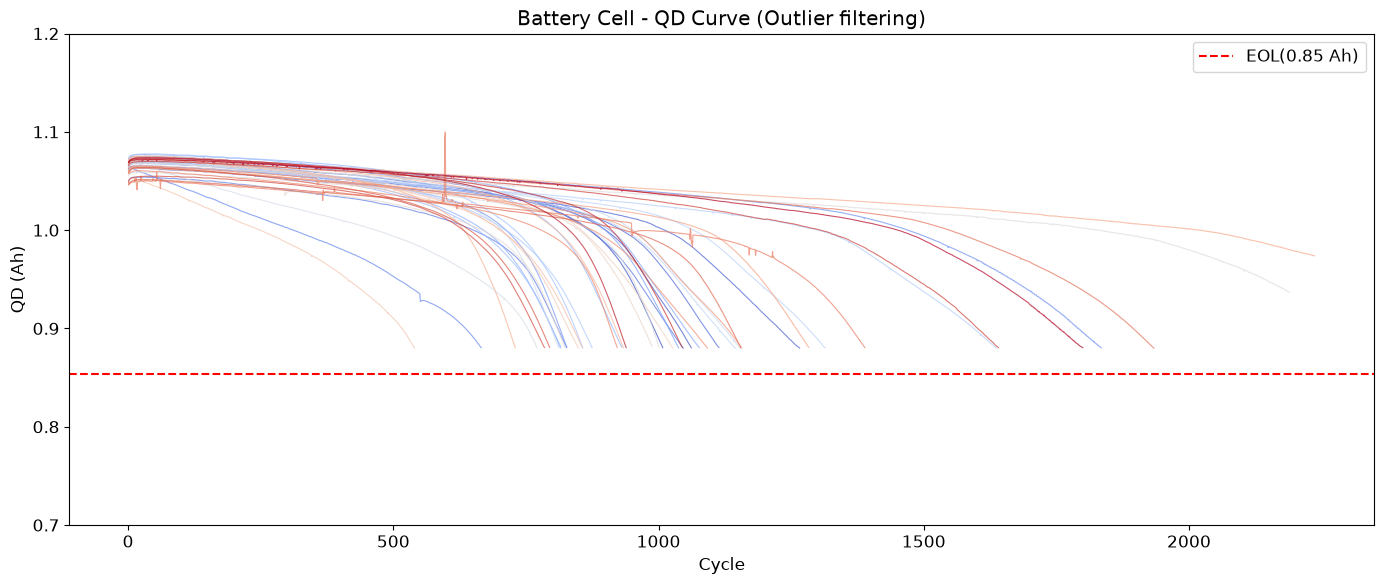

In [136]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

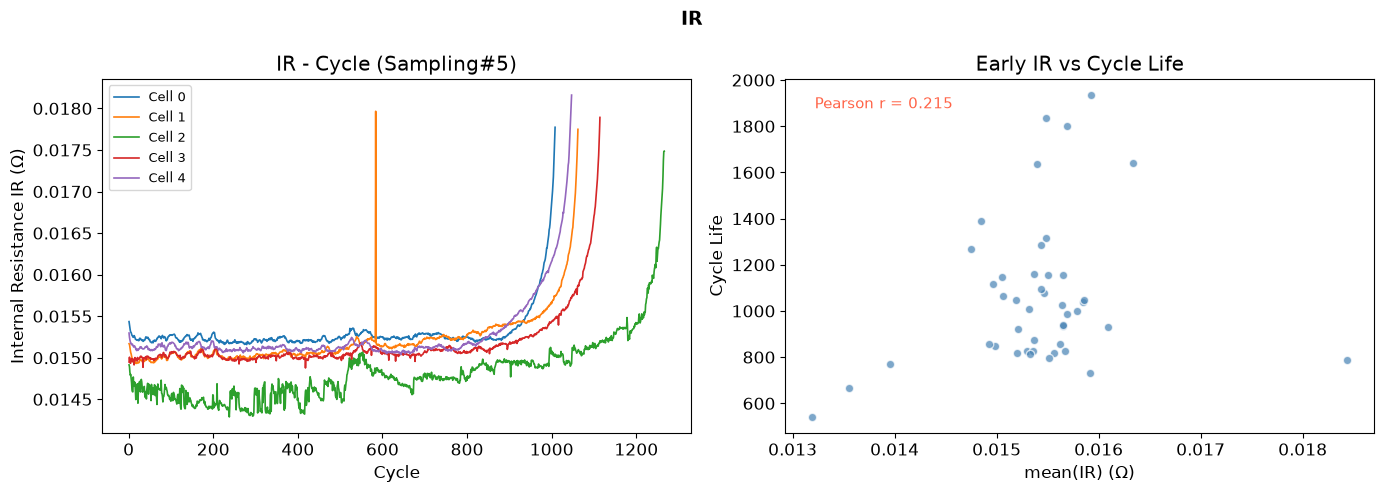

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

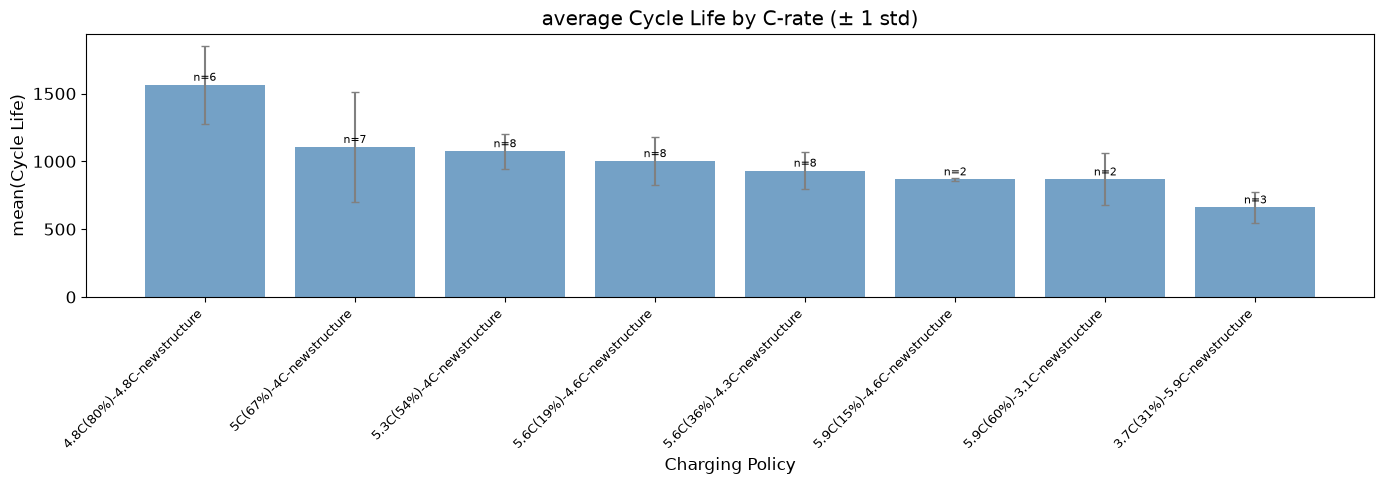

In [138]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

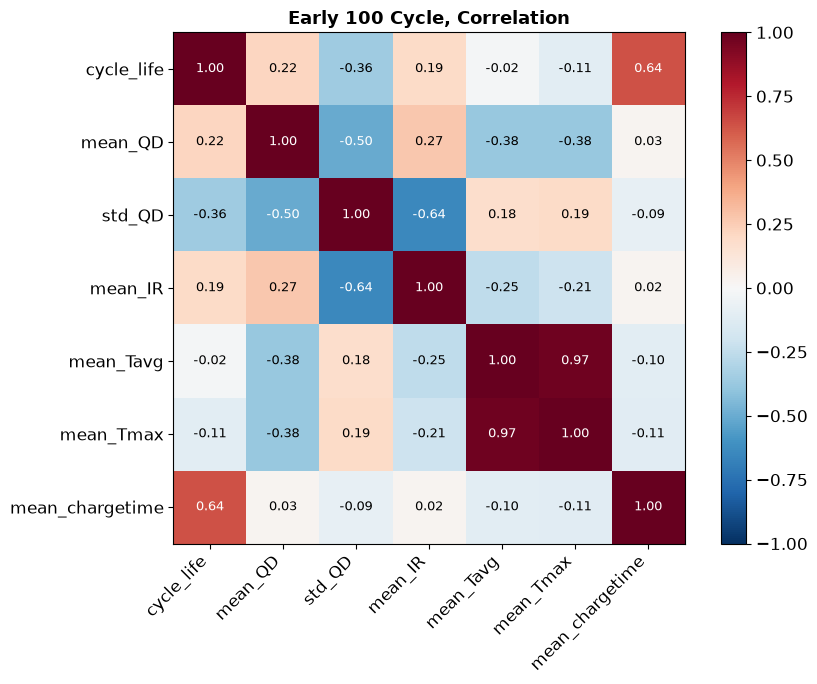


[cycle_life Corr Rank]
mean_chargetime    0.637
std_QD            -0.356
mean_QD            0.217
mean_IR            0.190
mean_Tmax         -0.106
mean_Tavg         -0.022
Name: cycle_life, dtype: float64


In [139]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

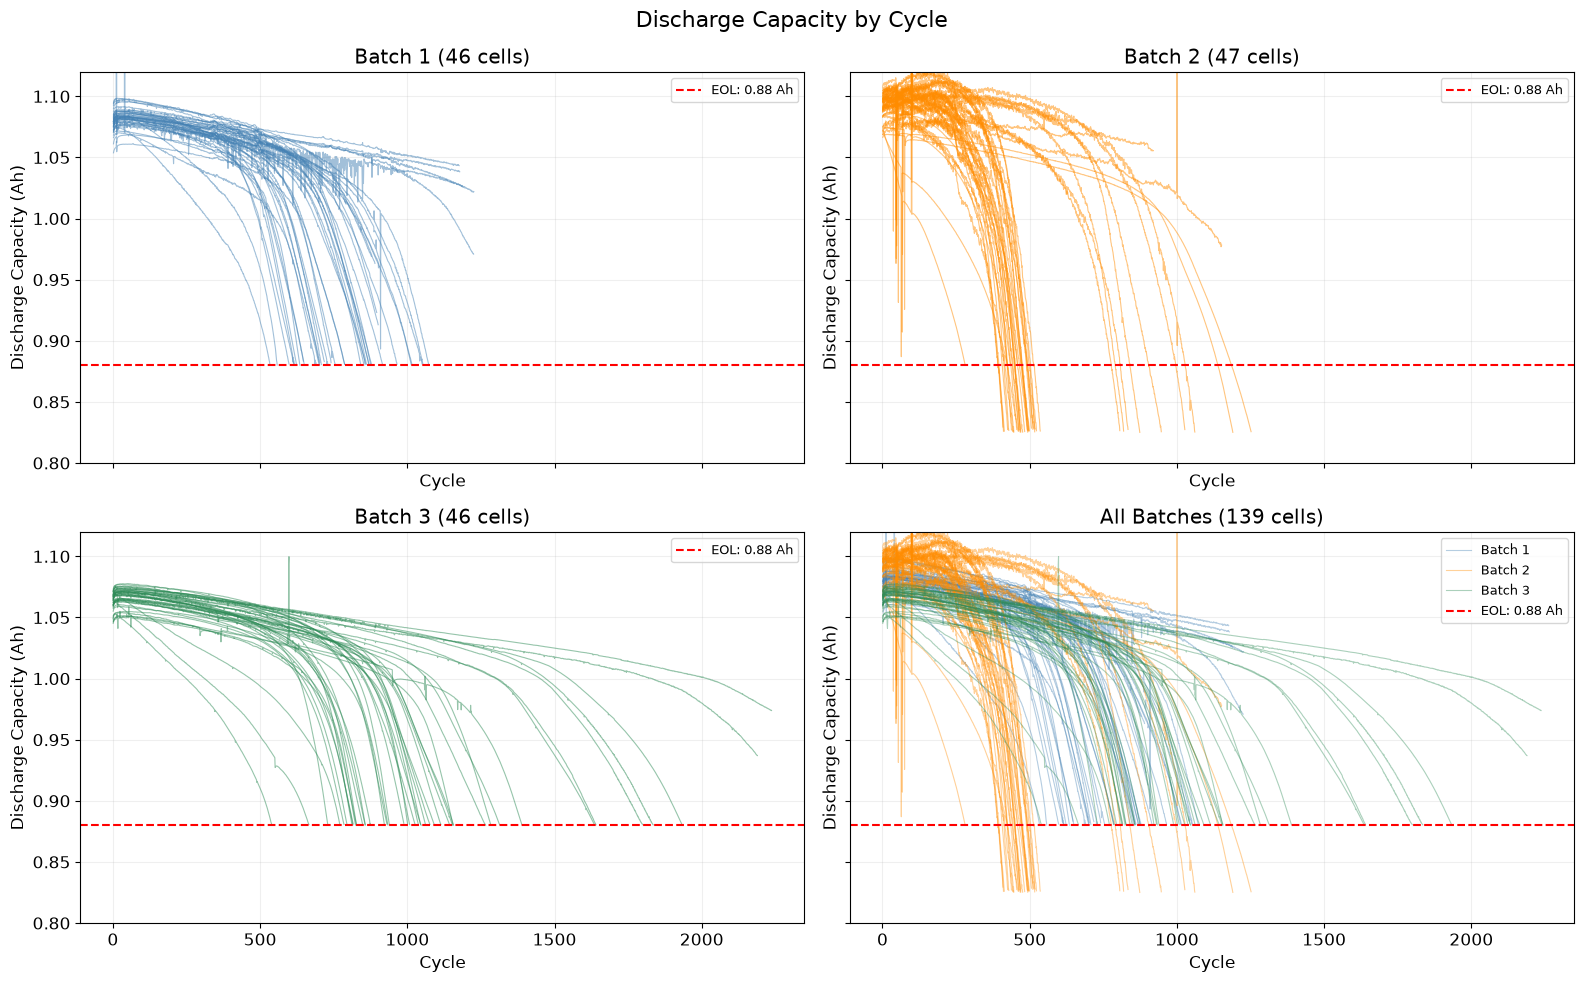

In [141]:
# Batch 1·2·3 및 전체 방전 용량 곡선 비교
degradation_frames = {}
for batch_label, loaded_mat in [('Batch 1', mat1), ('Batch 2', mat2), ('Batch 3', mat3)]:
    cells_for_plot = to_list_of_dicts(loaded_mat['batch'])
    frame_for_plot = extract_summary(cells_for_plot)
    frame_for_plot['batch_id'] = batch_label
    frame_for_plot = frame_for_plot.dropna(subset=['cycle', 'QD'])
    frame_for_plot = frame_for_plot[frame_for_plot['QD'] > 0].copy()
    degradation_frames[batch_label] = frame_for_plot

degradation_all = pd.concat(degradation_frames.values(), ignore_index=True)
batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'darkorange', 'Batch 3': 'seagreen'}

def add_cycle_life_guides(ax):
    ax.axvline(500, color='black', linestyle='--', linewidth=1.8, zorder=10, label='Short-life: 500')
    ax.axvline(1000, color='black', linestyle='-.', linewidth=1.8, zorder=10, label='Long-life: 1000')

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
for ax, (batch_label, frame_for_plot) in zip(axes.flat, degradation_frames.items()):
    for cid, sub in frame_for_plot.groupby('cell_id'):
        sub = sub.sort_values('cycle')
        ax.plot(sub['cycle'], sub['QD'], color=batch_colors[batch_label],
                linewidth=0.8, alpha=0.5)
    ax.set_title(f"{batch_label} ({frame_for_plot['cell_id'].nunique()} cells)")

ax = axes[1, 1]
for batch_label, frame_for_plot in degradation_all.groupby('batch_id', sort=False):
    first_curve = True
    for cid, sub in frame_for_plot.groupby('cell_id'):
        sub = sub.sort_values('cycle')
        ax.plot(sub['cycle'], sub['QD'], color=batch_colors[batch_label],
                linewidth=0.8, alpha=0.4,
                label=batch_label if first_curve else None)
        first_curve = False
total_cells = degradation_all[['batch_id', 'cell_id']].drop_duplicates().shape[0]
ax.set_title(f'All Batches ({total_cells} cells)')

for ax in axes.flat:
    ax.axhline(0.88, color='red', linestyle='--', label='EOL: 0.88 Ah')
    add_cycle_life_guides(ax)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Discharge Capacity (Ah)')
    ax.set_xlim(left=0)
    # 공칭 용량 주변의 열화를 같은 범위에서 비교합니다.
    ax.set_ylim(0.8, 1.12)
    ax.grid(alpha=0.2)
    ax.tick_params(labelbottom=True)
    ax.legend(fontsize=8, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.16))

fig.suptitle('Discharge Capacity by Cycle', fontsize=16)
fig.subplots_adjust(hspace=0.62, wspace=0.2, bottom=0.16, top=0.93)
plt.show()


In [ ]:
# 3. 초기 사이클의 ΔQ(V): 100회차 - 10회차
delta_records = []
for batch_label, loaded_mat in [('Batch 1', mat1), ('Batch 2', mat2), ('Batch 3', mat3)]:
    for cell_id, cell in enumerate(to_list_of_dicts(loaded_mat['batch'])):
        life = float(np.asarray(cell['cycle_life']).item())
        if not np.isfinite(life):
            continue
        cycles = to_list_of_dicts(cell['cycles'])
        if len(cycles) < 100:
            continue
        voltage = np.asarray(cell['Vdlin'], dtype=float).ravel()
        q10 = np.asarray(cycles[9]['Qdlin'], dtype=float).ravel()
        q100 = np.asarray(cycles[99]['Qdlin'], dtype=float).ravel()
        if voltage.size != q10.size or q10.size != q100.size:
            continue
        delta_q = q100 - q10
        valid = np.isfinite(voltage) & np.isfinite(delta_q)
        if valid.sum() < 2:
            continue
        delta_q = np.where(valid, delta_q, np.nan)
        delta_records.append({
            'batch_id': batch_label, 'cell_id': cell_id,
            'cycle_life': life, 'voltage': voltage,
            'delta_q': delta_q, 'delta_q_var': np.nanvar(delta_q),
        })

delta_df = pd.DataFrame(delta_records)
if delta_df.empty:
    raise ValueError('10회차와 100회차의 Qdlin 데이터가 없습니다.')

short = delta_df[delta_df['cycle_life'] < 500]
long = delta_df[delta_df['cycle_life'] > 1000]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for group, color, label in [(short, 'tomato', 'Short-life < 500'),
                            (long, 'steelblue', 'Long-life > 1000')]:
    if group.empty:
        continue
    for record in group.itertuples():
        axes[0].plot(record.voltage, record.delta_q, color=color,
                     linewidth=0.7, alpha=0.18)
    mean_curve = np.nanmean(np.stack(group['delta_q'].to_numpy()), axis=0)
    axes[0].plot(group.iloc[0]['voltage'], mean_curve, color=color,
                 linewidth=2.5, label=f'{label} (n={len(group)})')
axes[0].set_xlabel('Voltage (V)')
axes[0].set_ylabel('ΔQ100-10(V) (Ah)')
axes[0].set_title('Early discharge-curve change')
axes[0].grid(alpha=0.2)
axes[0].legend()

batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'darkorange', 'Batch 3': 'seagreen'}
for batch_label, group in delta_df.groupby('batch_id', sort=False):
    axes[1].scatter(group['delta_q_var'], group['cycle_life'],
                    s=28, alpha=0.7, color=batch_colors[batch_label],
                    label=batch_label)
axes[1].set_xscale('log')
axes[1].set_xlabel('Variance of ΔQ100-10(V) (Ah²)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('ΔQ variance vs cycle life')
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'분석 셀: {len(delta_df)}개 | 단수명 <500: {len(short)}개 | 장수명 >1000: {len(long)}개')
print(f'ΔQ 분산 중앙값 — 단수명: {short["delta_q_var"].median():.6g}, 장수명: {long["delta_q_var"].median():.6g}')


In [ ]:
# 4. 충전 정책(C-rate)과 수명, 전류와 관측된 용량 감소율
import re

policy_records = []
for batch_label, loaded_mat in [('Batch 1', mat1), ('Batch 2', mat2), ('Batch 3', mat3)]:
    for cell_id, cell in enumerate(to_list_of_dicts(loaded_mat['batch'])):
        life = float(np.asarray(cell['cycle_life']).item())
        if not np.isfinite(life):
            continue
        policy = str(cell.get('policy_readable') or cell.get('policy') or '')
        match = re.match(r'^([0-9.]+)C\(([0-9]+)%\)-([0-9.]+)C', policy)
        if match is None:
            continue
        c1, switch_soc, c2 = map(float, match.groups())
        # 0~80% SOC 구간을 두 충전 단계에 걸리는 시간으로 환산한 C-rate
        equivalent_c_rate = 80 / (switch_soc / c1 + (80 - switch_soc) / c2)

        qd = np.asarray(cell['summary']['QDischarge'], dtype=float).ravel()
        if len(qd) < 120:
            continue
        # 100회차 부근과 마지막 20회차의 중앙값으로 관측 구간의 평균 감소율 계산
        qd_early = np.nanmedian(qd[95:105])
        qd_late = np.nanmedian(qd[-20:])
        fade_rate = 1000 * (qd_early - qd_late) / (len(qd) - 110)  # mAh/cycle

        cycles_raw = cell['cycles']
        current_10 = (cycles_raw['I'][9] if isinstance(cycles_raw, dict)
                      else cycles_raw[9]['I'])
        current_10 = np.asarray(current_10, dtype=float).ravel()
        peak_charge_current = np.nanmax(current_10)

        policy_records.append({
            'batch_id': batch_label, 'cell_id': cell_id,
            'policy': policy, 'cycle_life': life,
            'C1': c1, 'switch_soc': switch_soc, 'C2': c2,
            'equivalent_c_rate': equivalent_c_rate,
            'peak_charge_current': peak_charge_current,
            'observed_fade_rate': fade_rate,
        })

policy_df = pd.DataFrame(policy_records)
if policy_df.empty:
    raise ValueError('분석할 충전 정책 데이터가 없습니다.')

policy_by_batch = (policy_df.groupby(['batch_id', 'policy'], as_index=False)
                   .agg(mean_life=('cycle_life', 'mean'),
                        n_cells=('cell_id', 'count'),
                        equivalent_c_rate=('equivalent_c_rate', 'first')))
policy_all = (policy_df.groupby('policy', as_index=False)
              .agg(mean_life=('cycle_life', 'mean'),
                   n_cells=('cell_id', 'count'),
                   equivalent_c_rate=('equivalent_c_rate', 'first')))

batch_colors = {'Batch 1': 'steelblue', 'Batch 2': 'darkorange', 'Batch 3': 'seagreen'}
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, batch_label in zip(axes.flat[:3], batch_colors):
    group = policy_by_batch[policy_by_batch['batch_id'] == batch_label]
    ax.scatter(group['equivalent_c_rate'], group['mean_life'],
               s=30 + 35 * group['n_cells'], alpha=0.7,
               color=batch_colors[batch_label], edgecolor='white')
    ax.set_title(f'{batch_label}: {len(group)} policies')
    ax.set_xlabel('Equivalent charge rate, 0–80% SOC (C)')
    ax.set_ylabel('Mean cycle life')
    ax.grid(alpha=0.2)

ax = axes[1, 1]
ax.scatter(policy_all['equivalent_c_rate'], policy_all['mean_life'],
           s=30 + 35 * policy_all['n_cells'], alpha=0.7,
           color='slategray', edgecolor='white')
ax.set_title(f'All Batches: {len(policy_all)} policies')
ax.set_xlabel('Equivalent charge rate, 0–80% SOC (C)')
ax.set_ylabel('Mean cycle life')
ax.grid(alpha=0.2)
fig.suptitle('Charging policy vs mean cycle life (point size = cell count)')
plt.show()

# 후기 용량 감소율은 탐색용 결과이며, 초기 수명 예측 모델의 입력으로 사용하지 않습니다.
fig, ax = plt.subplots(figsize=(9, 5))
for batch_label, group in policy_df.groupby('batch_id', sort=False):
    ax.scatter(group['peak_charge_current'], group['observed_fade_rate'],
               color=batch_colors[batch_label], alpha=0.7, s=28,
               label=batch_label)
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Peak positive I at cycle 10 (approximately C-rate)')
ax.set_ylabel('Observed mean QD decline after cycle 100 (mAh/cycle)')
ax.set_title('Charge current vs observed capacity decline')
ax.grid(alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

print(f'수명이 확인된 셀: {len(policy_df)}개')
print('\n정책별 평균 수명 — 긴 순서 상위 5개:')
print(policy_all.sort_values('mean_life', ascending=False).head(5).to_string(index=False))
print('\n정책별 평균 수명 — 짧은 순서 상위 5개:')
print(policy_all.sort_values('mean_life').head(5).to_string(index=False))
print('\n배치별 충전 속도·수명 Spearman 상관계수:')
for batch_label, group in policy_df.groupby('batch_id', sort=False):
    corr = group['equivalent_c_rate'].corr(group['cycle_life'], method='spearman')
    print(f'{batch_label}: {corr:.3f} (n={len(group)})')


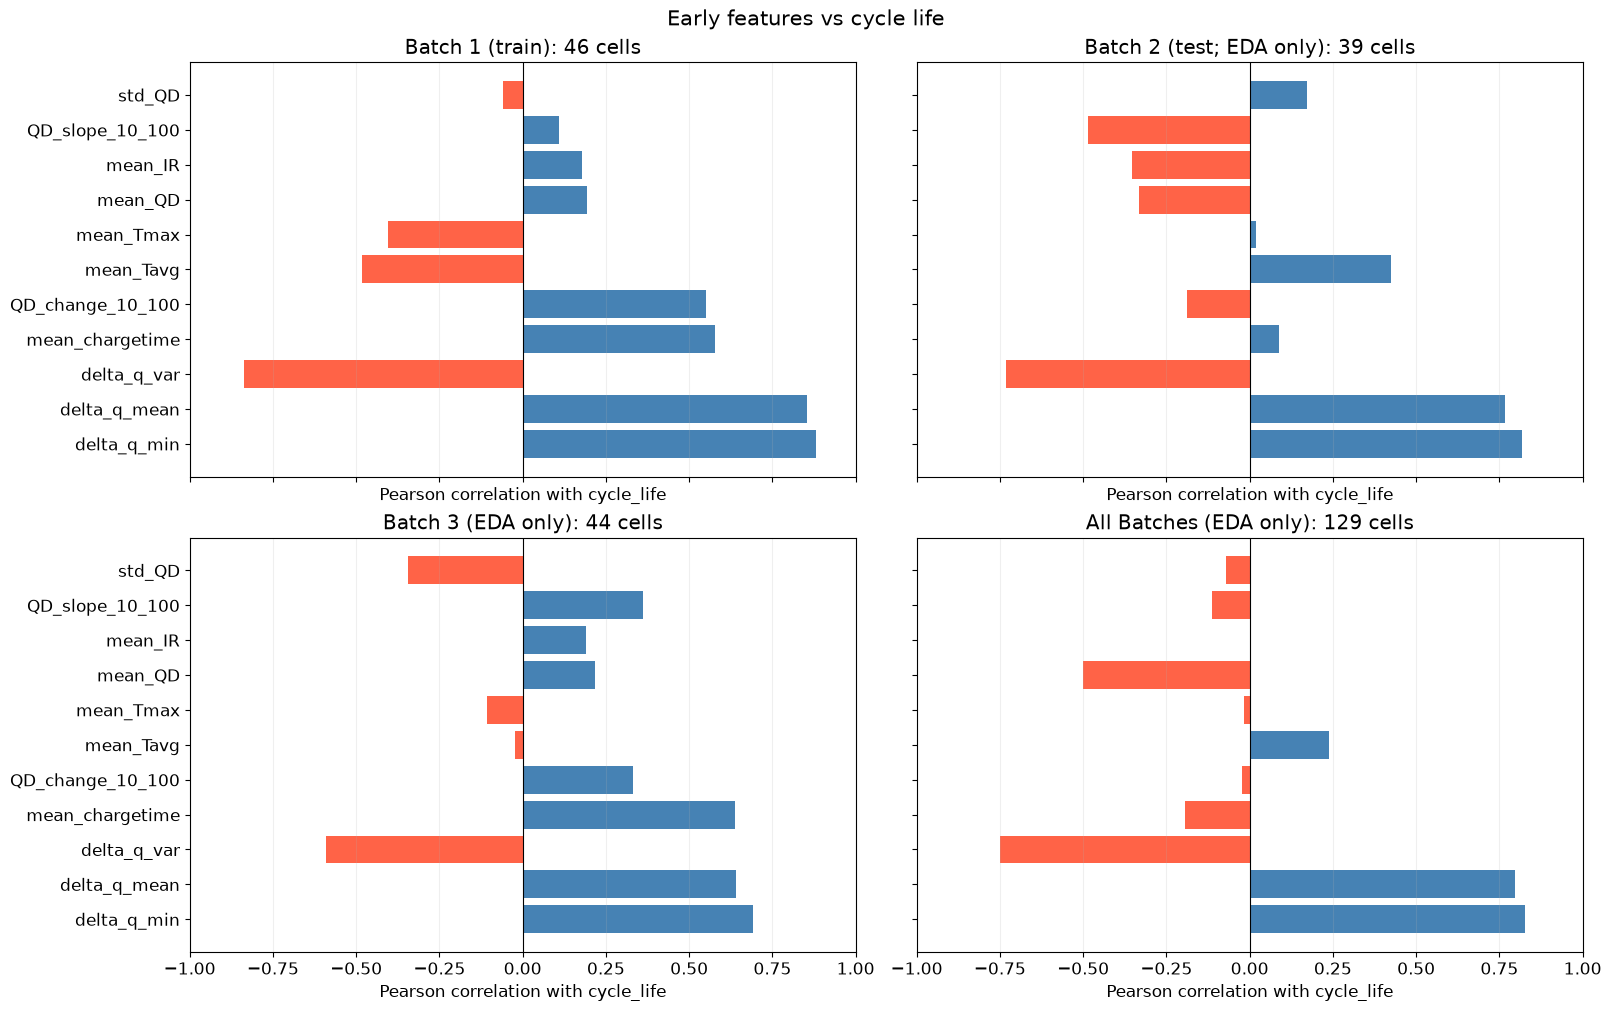

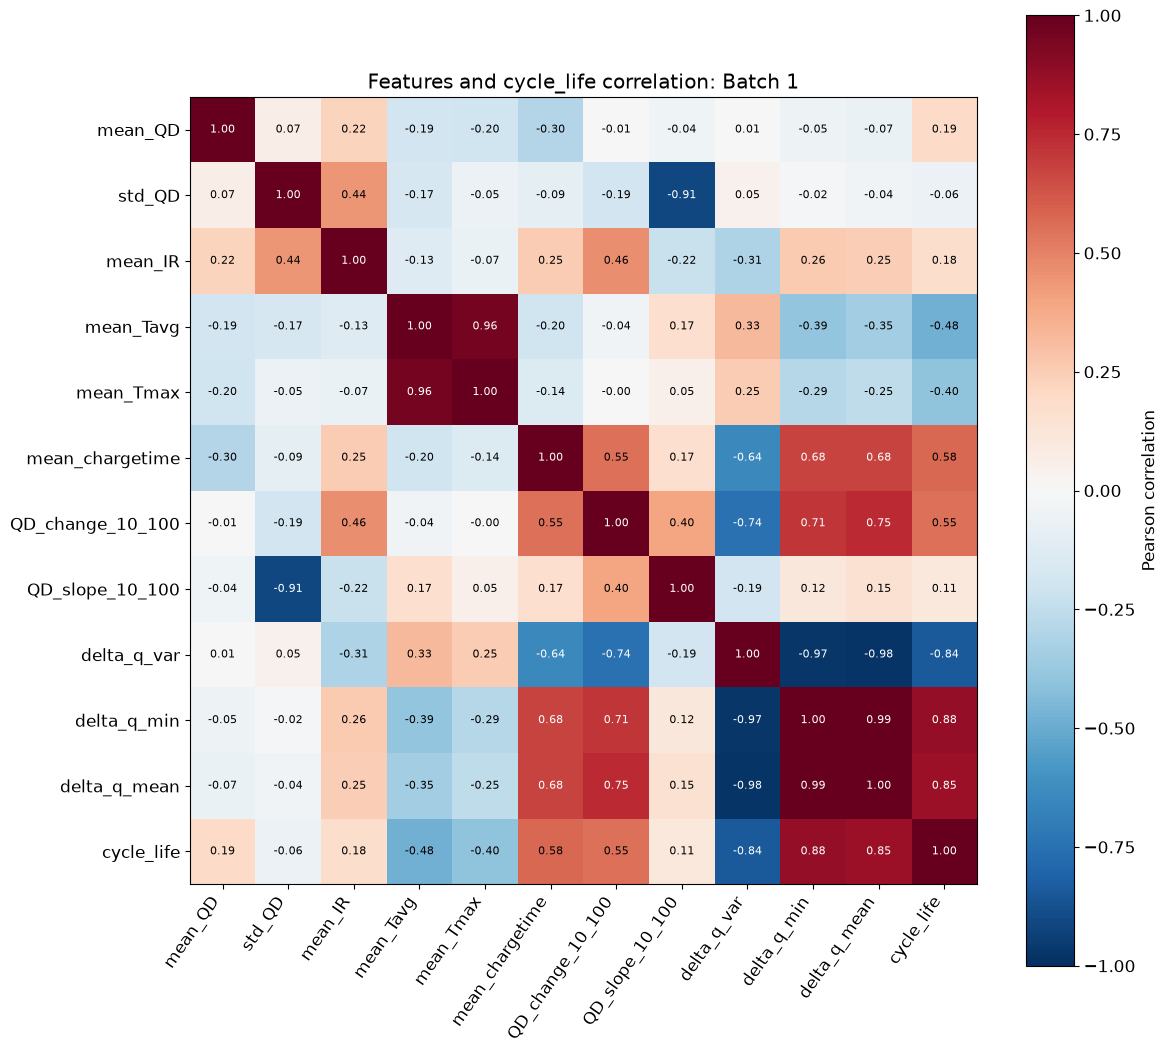

Batch 1: cycle_life와의 상관관계 (절댓값 순)
delta_q_min         0.882
delta_q_mean        0.854
delta_q_var        -0.838
mean_chargetime     0.577
QD_change_10_100    0.550
mean_Tavg          -0.482
mean_Tmax          -0.404
mean_QD             0.193
mean_IR             0.177
QD_slope_10_100     0.109
std_QD             -0.058

Batch 1: |상관계수| >= 0.8인 특징 쌍
delta_q_min ↔ delta_q_mean: 0.993
delta_q_var ↔ delta_q_mean: -0.977
delta_q_var ↔ delta_q_min: -0.974
mean_Tavg ↔ mean_Tmax: 0.956
std_QD ↔ QD_slope_10_100: -0.909


In [37]:
# 5. 초기 100사이클 특징과 수명 사이의 상관관계
feature_records = []
for batch_label, loaded_mat in [('Batch 1', mat1), ('Batch 2', mat2), ('Batch 3', mat3)]:
    for cell_id, cell in enumerate(to_list_of_dicts(loaded_mat['batch'])):
        life = float(np.asarray(cell['cycle_life']).item())
        if not np.isfinite(life):
            continue

        summary = cell['summary']
        names = ['QDischarge', 'IR', 'Tavg', 'Tmax', 'chargetime']
        values = {name: np.asarray(summary[name], dtype=float).ravel() for name in names}
        if any(len(values[name]) < 100 for name in names):
            continue
        qd = values['QDischarge']

        # 첫 사이클은 요약값이 0이므로 평균·표준편차에서 제외합니다.
        qd_early = qd[1:100]
        qd_fit = qd[9:100]  # 10~100회차
        fit_cycles = np.arange(10, 101)
        fit_valid = np.isfinite(qd_fit)
        qd_slope = (np.polyfit(fit_cycles[fit_valid], qd_fit[fit_valid], 1)[0]
                    if fit_valid.sum() >= 2 else np.nan)

        cycles_raw = cell['cycles']
        q10 = (cycles_raw['Qdlin'][9] if isinstance(cycles_raw, dict)
               else cycles_raw[9]['Qdlin'])
        q100 = (cycles_raw['Qdlin'][99] if isinstance(cycles_raw, dict)
                else cycles_raw[99]['Qdlin'])
        delta_q = np.asarray(q100, dtype=float).ravel() - np.asarray(q10, dtype=float).ravel()
        if not np.isfinite(delta_q).any():
            continue

        feature_records.append({
            'batch_id': batch_label, 'cell_id': cell_id, 'cycle_life': life,
            'mean_QD': np.nanmean(qd_early),
            'std_QD': np.nanstd(qd_early, ddof=1),
            'mean_IR': np.nanmean(values['IR'][1:100]),
            'mean_Tavg': np.nanmean(values['Tavg'][1:100]),
            'mean_Tmax': np.nanmean(values['Tmax'][1:100]),
            'mean_chargetime': np.nanmean(values['chargetime'][1:100]),
            'QD_change_10_100': qd[99] - qd[9],
            'QD_slope_10_100': qd_slope,
            'delta_q_var': np.nanvar(delta_q),
            'delta_q_min': np.nanmin(delta_q),
            'delta_q_mean': np.nanmean(delta_q),
        })

feature_df = pd.DataFrame(feature_records)
feature_cols = [
    'mean_QD', 'std_QD', 'mean_IR', 'mean_Tavg', 'mean_Tmax', 'mean_chargetime',
    'QD_change_10_100', 'QD_slope_10_100',
    'delta_q_var', 'delta_q_min', 'delta_q_mean',
]
if feature_df.empty:
    raise ValueError('상관관계를 계산할 배터리 데이터가 없습니다.')

# Batch 1 순위로 축 순서를 고정해 배치 간 차이를 비교합니다.
train_features = feature_df[feature_df['batch_id'] == 'Batch 1']
train_corr = train_features[feature_cols + ['cycle_life']].corr()['cycle_life'].drop('cycle_life')
feature_order = train_corr.abs().sort_values(ascending=False).index.tolist()
plot_groups = [
    ('Batch 1 (train)', train_features),
    ('Batch 2 (test; EDA only)', feature_df[feature_df['batch_id'] == 'Batch 2']),
    ('Batch 3 (EDA only)', feature_df[feature_df['batch_id'] == 'Batch 3']),
    ('All Batches (EDA only)', feature_df),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (title, group) in zip(axes.flat, plot_groups):
    corr = group[feature_cols + ['cycle_life']].corr()['cycle_life'].reindex(feature_order)
    y = np.arange(len(feature_order))
    valid = corr.notna().to_numpy()
    colors = np.where(corr[valid] >= 0, 'steelblue', 'tomato')
    ax.barh(y[valid], corr[valid], color=colors)
    ax.set_yticks(y, feature_order)
    ax.invert_yaxis()
    ax.set_xlim(-1, 1)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{title}: {len(group)} cells')
    ax.set_xlabel('Pearson correlation with cycle_life')
    ax.grid(axis='x', alpha=0.2)
fig.suptitle('Early features vs cycle life', fontsize=15)
plt.show()

# Batch 1의 입력 특징과 정답을 함께 표시합니다.
heatmap_cols = feature_cols + ['cycle_life']
feature_corr = train_features[heatmap_cols].corr()
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(feature_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(heatmap_cols)), heatmap_cols, rotation=55, ha='right')
ax.set_yticks(range(len(heatmap_cols)), heatmap_cols)
for i in range(len(heatmap_cols)):
    for j in range(len(heatmap_cols)):
        value = feature_corr.iloc[i, j]
        label = f'{value:.2f}' if np.isfinite(value) else '—'
        text_color = 'white' if np.isfinite(value) and abs(value) >= 0.6 else 'black'
        ax.text(j, i, label, ha='center', va='center', fontsize=8, color=text_color)
fig.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_title('Features and cycle_life correlation: Batch 1')
plt.tight_layout()
plt.show()

print('Batch 1: cycle_life와의 상관관계 (절댓값 순)')
print(train_corr.reindex(feature_order).round(3).to_string())
print('\nBatch 1: |상관계수| >= 0.8인 특징 쌍')
strong_pairs = []
for i, name1 in enumerate(feature_cols):
    for name2 in feature_cols[i + 1:]:
        value = feature_corr.loc[name1, name2]
        if np.isfinite(value) and abs(value) >= 0.8:
            strong_pairs.append((name1, name2, value))
for name1, name2, value in sorted(strong_pairs, key=lambda item: abs(item[2]), reverse=True):
    print(f'{name1} ↔ {name2}: {value:.3f}')
if not strong_pairs:
    print('없음')
